In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
#데이터 불러오기
df =pd.read_csv("dataset/sleep_health_dataset.csv")
df.head()

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


In [3]:
#데이터 null 개수 확인
df.isnull().sum()

person_id                      0
age                            0
gender                         0
occupation                     0
bmi                            0
country                        0
sleep_duration_hrs             0
sleep_quality_score            0
rem_percentage                 0
deep_sleep_percentage          0
sleep_latency_mins             0
wake_episodes_per_night        0
caffeine_mg_before_bed         0
alcohol_units_before_bed       0
screen_time_before_bed_mins    0
exercise_day                   0
steps_that_day                 0
nap_duration_mins              0
stress_score                   0
work_hours_that_day            0
chronotype                     0
mental_health_condition        0
heart_rate_resting_bpm         0
sleep_aid_used                 0
shift_work                     0
room_temperature_celsius       0
weekend_sleep_diff_hrs         0
season                         0
day_type                       0
cognitive_performance_score    0
sleep_diso

In [4]:
# 데이터 타입 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   occupation                   100000 non-null  object 
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  object 
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  

In [5]:
#데이터 중복 개수 확인
df.duplicated().sum()

np.int64(0)

In [6]:
#데이터 통계 확인
df.describe()

,person_id,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,...,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,34.706870,26.289673,6.423986,4.871144,20.243968,20.253375,19.836810,3.346610,38.849500,...,14.936840,5.733285,7.134059,66.57017,0.561610,0.084420,20.538093,1.200634,59.227295,0.390120
std,28867.657797,11.036373,4.479578,1.274627,1.506517,3.411354,4.251096,7.584343,1.920877,69.395818,...,21.387567,1.619194,3.482878,7.22821,0.496192,0.278018,2.897565,0.786667,22.249665,0.487779
min,1.000000,18.000000,16.000000,3.000000,1.000000,10.000000,5.000000,1.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,45.00000,0.000000,0.000000,15.000000,-1.000000,0.000000,0.000000
25%,25000.750000,26.000000,23.200000,5.530000,3.800000,18.000000,17.400000,14.000000,2.000000,0.000000,...,0.000000,4.800000,4.700000,62.00000,0.000000,0.000000,18.500000,0.670000,44.200000,0.000000
50%,50000.500000,33.000000,26.300000,6.360000,4.900000,20.300000,20.300000,19.000000,3.000000,0.000000,...,0.000000,5.800000,7.400000,67.00000,1.000000,0.000000,20.500000,1.200000,60.400000,0.000000
75%,75000.250000,42.000000,29.300000,7.270000,6.000000,22.600000,23.200000,25.000000,5.000000,80.000000,...,30.000000,6.800000,9.700000,71.00000,1.000000,0.000000,22.500000,1.740000,75.800000,1.000000
max,100000.000000,69.000000,45.000000,10.500000,10.000000,30.000000,30.000000,58.000000,8.000000,400.000000,...,116.000000,10.000000,18.000000,99.00000,1.000000,1.000000,28.000000,3.000000,100.000000,1.000000


In [9]:
# 타겟 분포 확인 -> 골고루 분포되어 있음
df['sleep_quality_score'].value_counts().sort_index()

sleep_quality_score
1.0     526
1.1     133
1.2     145
1.3     169
1.4     182
       ... 
9.4       5
9.5       2
9.6       3
9.7       1
10.0      1
Name: count, Length: 89, dtype: int64

array([[<Axes: title={'center': 'person_id'}>,
        <Axes: title={'center': 'age'}>, <Axes: title={'center': 'bmi'}>,
        <Axes: title={'center': 'sleep_duration_hrs'}>,
        <Axes: title={'center': 'sleep_quality_score'}>],
       [<Axes: title={'center': 'rem_percentage'}>,
        <Axes: title={'center': 'deep_sleep_percentage'}>,
        <Axes: title={'center': 'sleep_latency_mins'}>,
        <Axes: title={'center': 'wake_episodes_per_night'}>,
        <Axes: title={'center': 'caffeine_mg_before_bed'}>],
       [<Axes: title={'center': 'alcohol_units_before_bed'}>,
        <Axes: title={'center': 'screen_time_before_bed_mins'}>,
        <Axes: title={'center': 'exercise_day'}>,
        <Axes: title={'center': 'steps_that_day'}>,
        <Axes: title={'center': 'nap_duration_mins'}>],
       [<Axes: title={'center': 'stress_score'}>,
        <Axes: title={'center': 'work_hours_that_day'}>,
        <Axes: title={'center': 'heart_rate_resting_bpm'}>,
        <Axes: title={'c

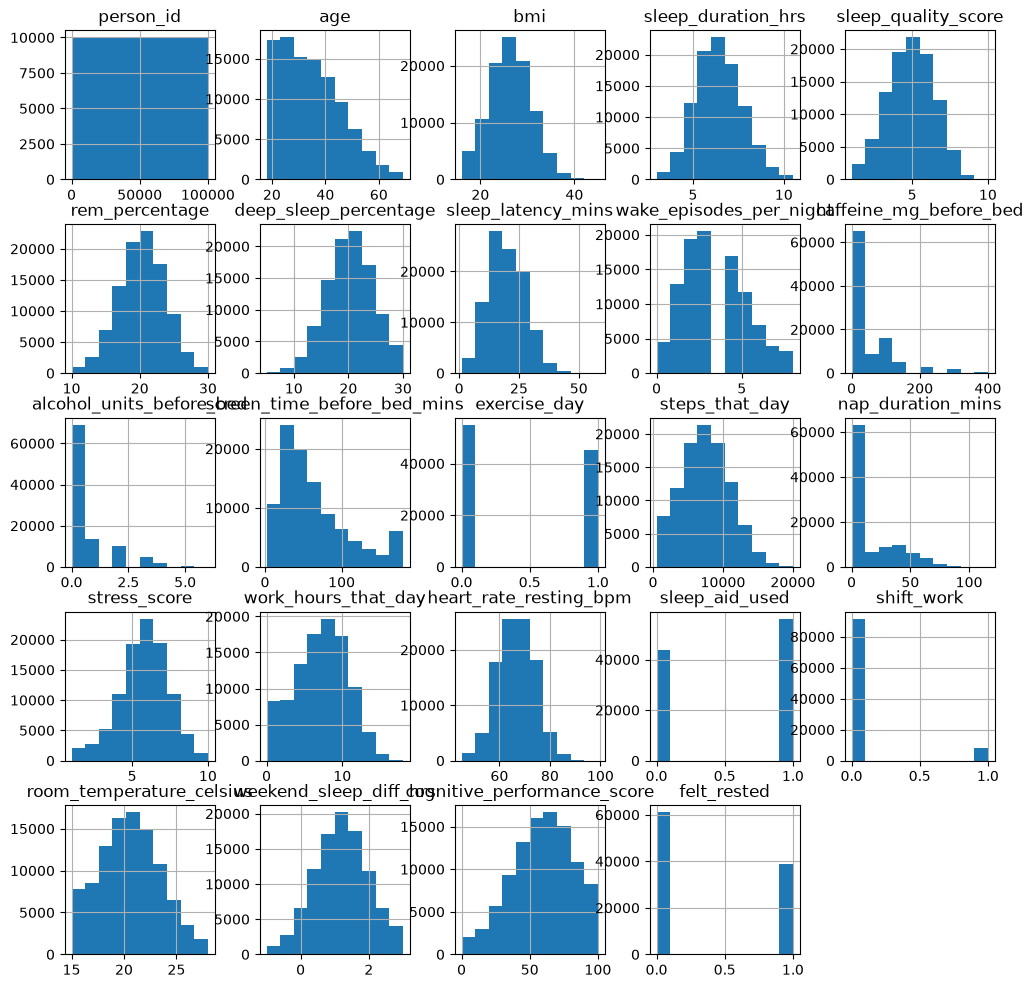

In [10]:
#EDA 히스토그램 확인
df.hist(figsize=(12,12))

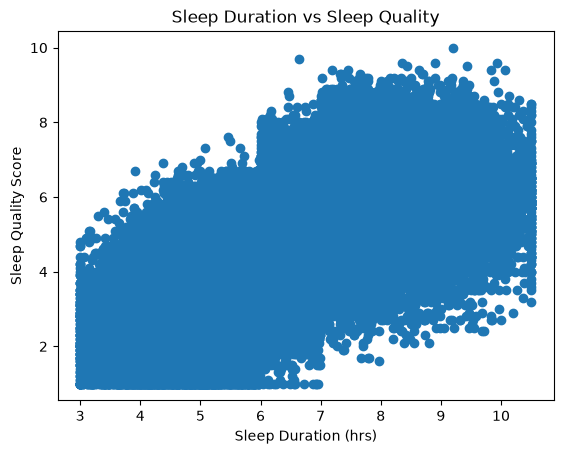

In [11]:
# 수면의 질과 수면 시간의 관계

plt.scatter(df['sleep_duration_hrs'], df['sleep_quality_score'])

plt.xlabel('Sleep Duration (hrs)')
plt.ylabel('Sleep Quality Score')
plt.title('Sleep Duration vs Sleep Quality')

plt.show()

In [12]:
#상관관계 확인
corr = df.corr(numeric_only=True)
corr

,person_id,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,...,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
person_id,1.000000,-0.001380,0.003111,-0.000461,0.001707,-0.000955,-0.000016,-0.004686,0.001194,-0.000116,...,0.002721,-0.001803,0.000296,-0.000304,0.002205,0.003832,-0.003260,-0.003452,0.001601,-0.000301
age,-0.001380,1.000000,0.103981,-0.000007,-0.025463,0.001637,-0.465001,0.001460,0.105135,0.002562,...,0.003280,0.000183,0.003811,0.000869,0.002556,-0.001034,-0.004103,0.001474,-0.067792,-0.019091
bmi,0.003111,0.103981,1.000000,0.002684,-0.057350,0.000687,-0.047179,0.003584,0.236141,0.001546,...,0.001856,-0.000628,0.001496,-0.004647,-0.005731,0.000309,0.005796,0.000040,-0.037134,-0.047608
sleep_duration_hrs,-0.000461,-0.000007,0.002684,1.000000,0.646462,0.060164,0.047324,-0.130711,-0.105429,-0.019636,...,-0.061856,-0.500027,-0.442517,-0.049519,0.114719,-0.226757,0.003566,-0.004523,0.618241,0.443114
sleep_quality_score,0.001707,-0.025463,-0.057350,0.646462,1.000000,0.253873,0.090631,-0.292933,-0.381230,-0.050373,...,-0.016058,-0.638828,-0.368638,-0.066450,0.049500,-0.263407,-0.023046,-0.005765,0.859978,0.478843
rem_percentage,-0.000955,0.001637,0.000687,0.060164,0.253873,1.000000,0.123002,-0.027007,-0.071330,-0.001473,...,0.000904,-0.157599,-0.063190,-0.039098,-0.005829,-0.018283,-0.001036,0.002071,0.445967,0.119252
deep_sleep_percentage,-0.000016,-0.465001,-0.047179,0.047324,0.090631,0.123002,1.000000,-0.020101,-0.081555,-0.004368,...,0.002897,-0.091957,-0.038725,-0.045537,-0.007028,-0.011637,0.003055,-0.000316,0.280368,0.051823
sleep_latency_mins,-0.004686,0.001460,0.003584,-0.130711,-0.292933,-0.027007,-0.020101,1.000000,0.033195,0.320784,...,-0.005243,0.169121,0.049993,0.021381,0.000319,0.019286,0.002345,0.006039,-0.225244,-0.127440
wake_episodes_per_night,0.001194,0.105135,0.236141,-0.105429,-0.381230,-0.071330,-0.081555,0.033195,1.000000,0.004932,...,-0.005214,0.175057,0.084806,0.017997,-0.005434,0.143941,-0.002598,-0.000971,-0.294673,-0.226104
caffeine_mg_before_bed,-0.000116,0.002562,0.001546,-0.019636,-0.050373,-0.001473,-0.004368,0.320784,0.004932,1.000000,...,0.002529,-0.000539,0.001350,0.004022,-0.001872,-0.000989,0.002687,0.001614,-0.065320,-0.025494


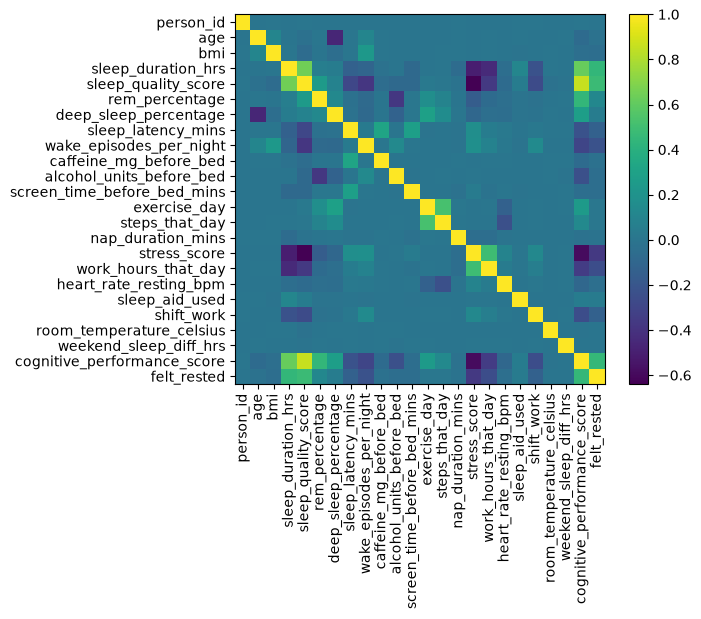

In [13]:
plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.show()

In [15]:
corr = df.corr(numeric_only=True)

corr['sleep_quality_score'].sort_values(ascending=False)

sleep_quality_score            1.000000
cognitive_performance_score    0.859978
sleep_duration_hrs             0.646462
felt_rested                    0.478843
rem_percentage                 0.253873
deep_sleep_percentage          0.090631
sleep_aid_used                 0.049500
exercise_day                   0.021506
steps_that_day                 0.014140
person_id                      0.001707
weekend_sleep_diff_hrs        -0.005765
nap_duration_mins             -0.016058
room_temperature_celsius      -0.023046
age                           -0.025463
caffeine_mg_before_bed        -0.050373
bmi                           -0.057350
heart_rate_resting_bpm        -0.066450
screen_time_before_bed_mins   -0.079158
alcohol_units_before_bed      -0.080920
shift_work                    -0.263407
sleep_latency_mins            -0.292933
work_hours_that_day           -0.368638
wake_episodes_per_night       -0.381230
stress_score                  -0.638828
Name: sleep_quality_score, dtype: float6

In [ ]:
df = df.drop(columns=[
    
])